<a href="https://colab.research.google.com/github/SheilandraZarawiba/PCVK_2026/blob/main/Week5_24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# Identitas dan Parameter PCVK Modul 5

import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Sheilandra Zarawiba'
NIM = '244107020110'

N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1)
}

waktu = datetime.datetime.now(
    zoneinfo.ZoneInfo('Asia/Jakarta')
)

print('NAMA :', NAMA)
print('NIM  :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s:' % k, v)

print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S WIB'))
print('SISTEM:', sys.version.split()[0], platform.platform())

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Sheilandra Zarawiba
NIM  : 244107020110 | N = 110
bins  : 32
clip  : 1.0
tile  : 4
L     : 8
WAKTU : 2026-09-29 20:08:33 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : d3ffd218775eb0c6


E-1 PERCOBAAN HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

In [13]:
# Lokasi folder gambar contoh
CONTOH = '/content/drive/MyDrive/PCVK/Gambar'

# Lokasi folder KTM milik sendiri
BASE = '/content/drive/MyDrive/PCVK/Gambar/244107020110'

# Cek isi folder
import os

NIM = '244107020110'

print("Isi folder contoh:", os.listdir(CONTOH))
print("Isi folder KTM:", os.listdir(BASE))

Isi folder contoh: ['.ipynb_checkpoints', 'ktm.jpg', 'houses.jpg', 'apel.jpg', 'galaxy.jpg', 'couple.png', 'night.jpg', 'crayfish.png', 'lena.jpg', 'lena_lc.jpg', '244107020110']
Isi folder KTM: ['KTM1b.jpg', 'KTM1a.jpg', 'KTM1c.jpg', 'KTM1d.jpg']


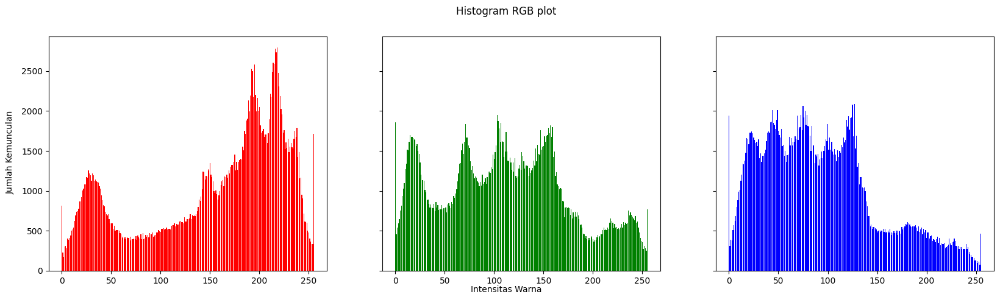

In [10]:
# Membuat histogram image (manual)

img = cv.imread('/content/drive/MyDrive/PCVK/Gambar/lena.jpg')

if img is None:
    print("Gambar Lena tidak ditemukan. Periksa lokasi dan nama file.")
else:
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    height, width, depth = np.shape(img)

    names = np.arange(256)

    red = [0] * 256
    green = [0] * 256
    blue = [0] * 256

    for y in range(0, height):
        for x in range(0, width):
            red[img[y][x][0]] += 1
            green[img[y][x][1]] += 1
            blue[img[y][x][2]] += 1

    fig, axs = plt.subplots(1, 3, figsize=(20, 5),
                            sharex=True, sharey=True)

    fig.suptitle('Histogram RGB plot')

    fig.text(0.09, 0.5, 'Jumlah Kemunculan',
             va='center', rotation='vertical')

    fig.text(0.5, 0.04, 'Intensitas Warna',
             ha='center')

    axs[0].bar(names, red, color='red')
    axs[1].bar(names, green, color='green')
    axs[2].bar(names, blue, color='blue')

    plt.show()

PERTANYAAN PRAKTIKUM E1



 Lena
Manual - NumPy: 0
Manual - CV2: 0
NumPy - CV2: 0


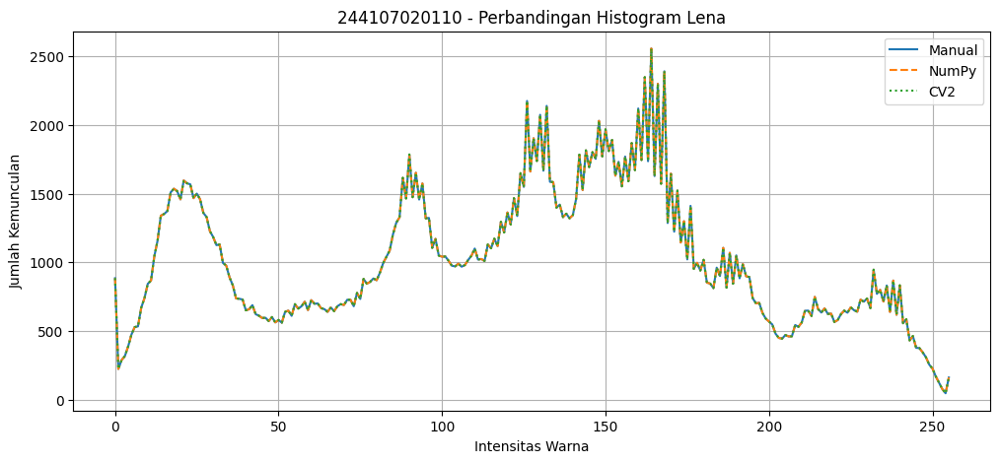


 KTM1b
Manual - NumPy: 0
Manual - CV2: 0
NumPy - CV2: 0


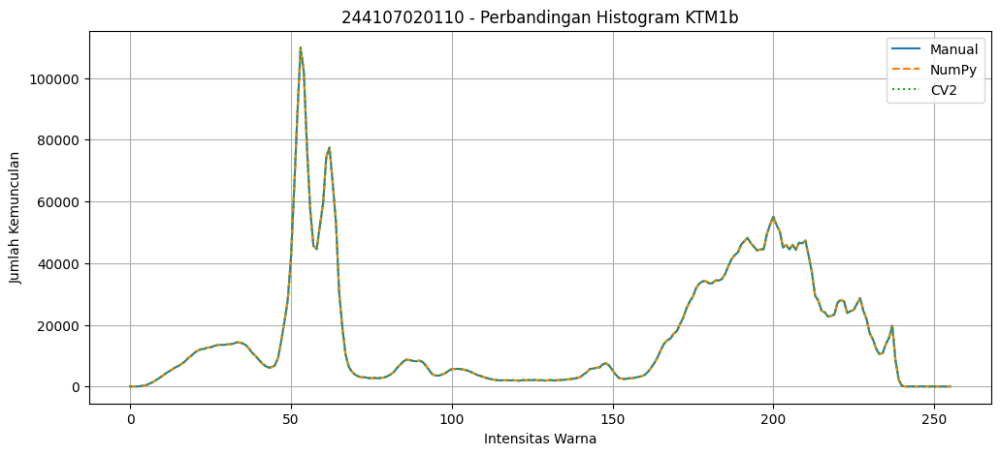

In [14]:
# E1 - Nomor 1
# Perbandingan histogram Manual, NumPy, dan CV2

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

# Tahap 1: Lena dan Tahap 2: KTM1b
for nama, path in [
    ('Lena', CONTOH + '/lena.jpg'),
    ('KTM1b', BASE + '/KTM1b.jpg')
]:

    img = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if img is None:
        print(nama, 'tidak ditemukan:', path)
        continue

    # Histogram manual
    h_manual = histogram_manual(img)

    # Histogram NumPy
    h_numpy, _ = np.histogram(
        img, bins=256, range=(0, 256)
    )

    # Histogram CV2
    h_cv = cv.calcHist(
        [img], [0], None, [256], [0, 256]
    ).flatten().astype(np.int64)

    # Selisih maksimum
    print('\n', nama)
    print('Manual - NumPy:',
          np.max(np.abs(h_manual - h_numpy)))
    print('Manual - CV2:',
          np.max(np.abs(h_manual - h_cv)))
    print('NumPy - CV2:',
          np.max(np.abs(h_numpy - h_cv)))

    # Grafik perbandingan
    plt.figure(figsize=(12, 5))
    plt.plot(h_manual, label='Manual')
    plt.plot(h_numpy, '--', label='NumPy')
    plt.plot(h_cv, ':', label='CV2')

    plt.title(NIM + ' - Perbandingan Histogram ' + nama)
    plt.xlabel('Intensitas Warna')
    plt.ylabel('Jumlah Kemunculan')
    plt.legend()
    plt.grid()
    plt.show()

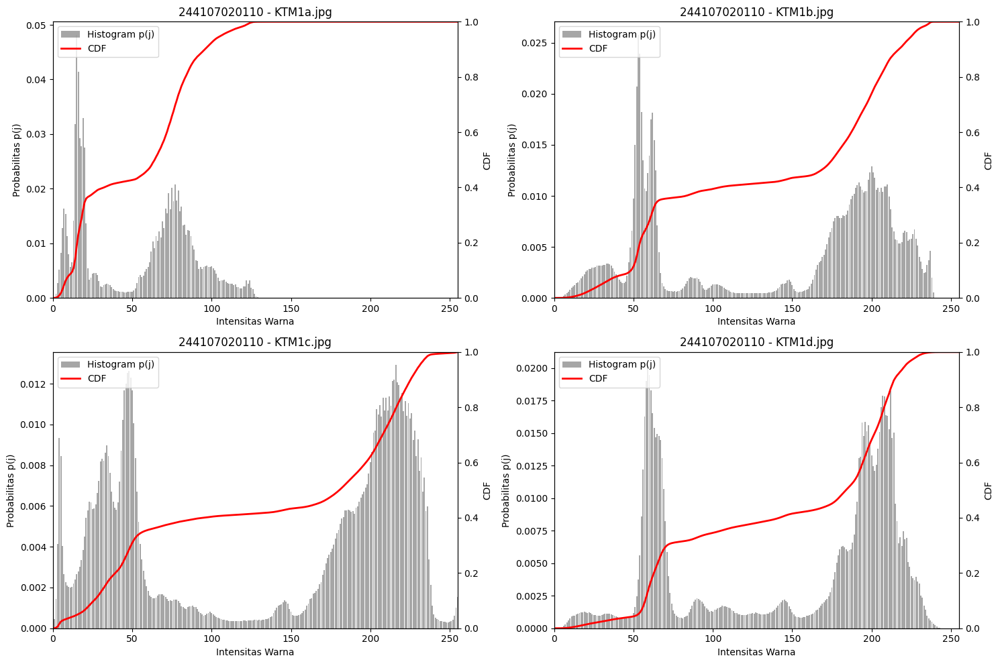

In [15]:
# E1 - Nomor 2
# Histogram ternormalisasi dan CDF KTM1a sampai KTM1d

nama_file = [
    'KTM1a.jpg', 'KTM1b.jpg',
    'KTM1c.jpg', 'KTM1d.jpg'
]

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

for i, nama in enumerate(nama_file):

    img = cv.imread(
        BASE + '/' + nama,
        cv.IMREAD_GRAYSCALE
    )

    if img is None:
        print(nama, 'tidak ditemukan!')
        continue

    # Histogram manual dan normalisasi
    h = histogram_manual(img)
    p = h / img.size

    # CDF
    cdf = np.cumsum(p)

    ax = axs[i // 2, i % 2]

    # Histogram ternormalisasi
    ax.bar(
        np.arange(256), p,
        color='gray', alpha=0.7,
        label='Histogram p(j)'
    )

    ax.set_title(NIM + ' - ' + nama)
    ax.set_xlabel('Intensitas Warna')
    ax.set_ylabel('Probabilitas p(j)')
    ax.set_xlim(0, 255)

    # CDF pada sumbu kanan
    ax2 = ax.twinx()
    ax2.plot(
        np.arange(256), cdf,
        color='red', linewidth=2,
        label='CDF'
    )

    ax2.set_ylabel('CDF')
    ax2.set_ylim(0, 1)

    # Gabungkan legenda
    garis1, label1 = ax.get_legend_handles_labels()
    garis2, label2 = ax2.get_legend_handles_labels()

    ax.legend(
        garis1 + garis2,
        label1 + label2,
        loc='upper left'
    )

plt.tight_layout()
plt.show()

In [17]:
# Parameter berdasarkan 3 digit terakhir NIM

N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1)
}

print(PARAM)

{'bins': 32, 'clip': 1.0, 'tile': 4, 'L': 8}


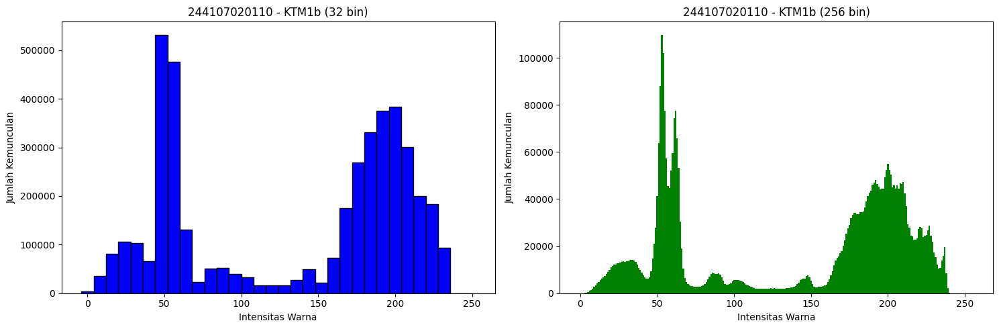

Jumlah bin berdasarkan NIM: 32


In [18]:
# E1 - Nomor 3
# Histogram KTM1b dengan PARAM['bins'] dan 256 bin

img = cv.imread(
    BASE + '/KTM1b.jpg',
    cv.IMREAD_GRAYSCALE
)

if img is None:
    print('KTM1b.jpg tidak ditemukan!')
else:
    hist_bins, batas_bins = np.histogram(
        img,
        bins=PARAM['bins'],
        range=(0, 256)
    )

    hist_256, batas_256 = np.histogram(
        img,
        bins=256,
        range=(0, 256)
    )

    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    axs[0].bar(
        batas_bins[:-1],
        hist_bins,
        width=256 / PARAM['bins'],
        color='blue',
        edgecolor='black'
    )

    axs[0].set_title(
        NIM + ' - KTM1b (' + str(PARAM['bins']) + ' bin)'
    )
    axs[0].set_xlabel('Intensitas Warna')
    axs[0].set_ylabel('Jumlah Kemunculan')

    axs[1].bar(
        batas_256[:-1],
        hist_256,
        width=1,
        color='green'
    )

    axs[1].set_title(NIM + ' - KTM1b (256 bin)')
    axs[1].set_xlabel('Intensitas Warna')
    axs[1].set_ylabel('Jumlah Kemunculan')

    plt.tight_layout()
    plt.show()

    print('Jumlah bin berdasarkan NIM:', PARAM['bins'])

E-2 PERCOBAAN HISTOGRAM EQUALIZATION

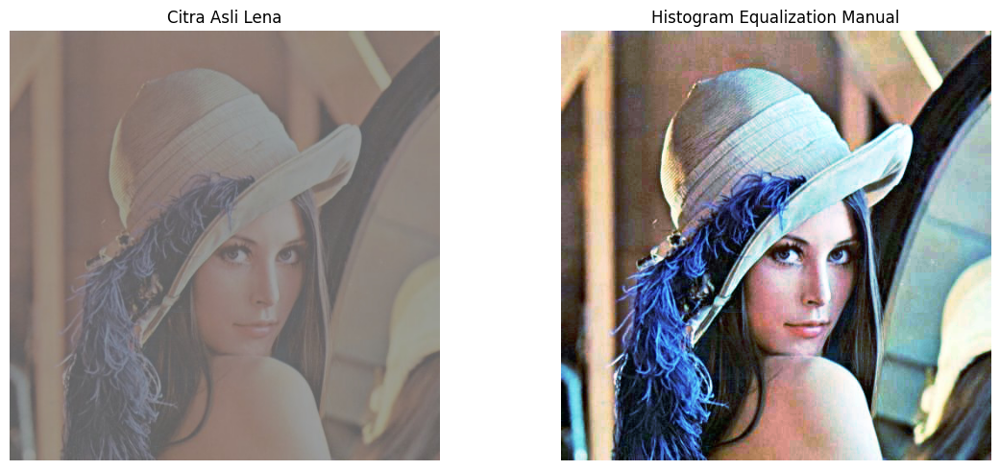

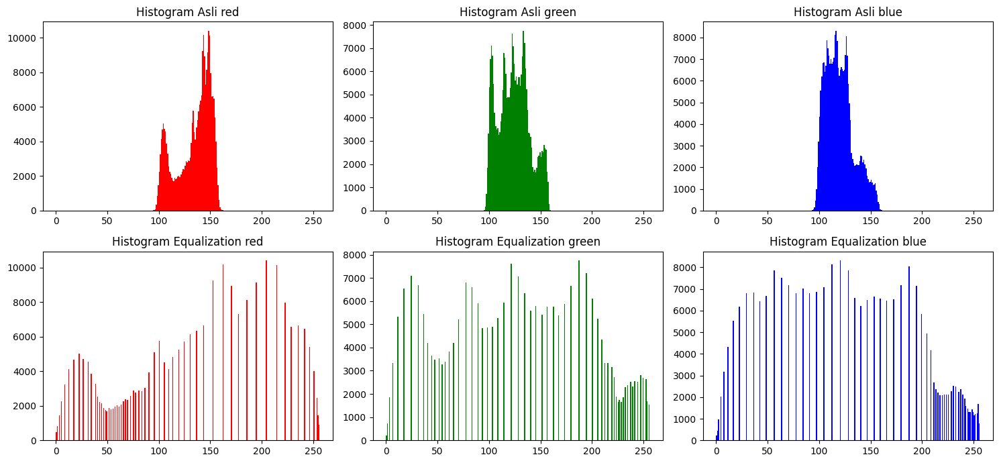

In [21]:
# E-2 - Histogram Equalization Manual pada Lena (RGB)

img = cv.imread(CONTOH + '/lena_lc.jpg')

if img is None:
    print("Gambar Lena tidak ditemukan")
else:
    # Konversi BGR ke RGB
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # Fungsi histogram equalization manual
    def equalize_manual(kanal):
        h = np.zeros(256, dtype=np.int64)

        for y in range(kanal.shape[0]):
            for x in range(kanal.shape[1]):
                h[kanal[y, x]] += 1

        # Menghitung CDF
        cdf = np.cumsum(h)
        cdf_min = cdf[cdf > 0].min()

        # Transformasi intensitas
        cdf_norm = (cdf - cdf_min) / (kanal.size - cdf_min)
        cdf_norm = np.clip(cdf_norm * 255, 0, 255)

        transformasi = np.round(cdf_norm).astype(np.uint8)

        return transformasi[kanal]

    # Memisahkan kanal RGB
    r, g, b = cv.split(img)

    # Equalization masing-masing kanal
    r_eq = equalize_manual(r)
    g_eq = equalize_manual(g)
    b_eq = equalize_manual(b)

    # Menggabungkan kembali kanal
    hasil_manual = cv.merge([r_eq, g_eq, b_eq])

    # Menampilkan citra asli dan hasil
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].imshow(img)
    axs[0].set_title('Citra Asli Lena')
    axs[0].axis('off')

    axs[1].imshow(hasil_manual)
    axs[1].set_title('Histogram Equalization Manual')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Histogram RGB sebelum dan sesudah
    fig, axs = plt.subplots(2, 3, figsize=(15, 7))

    warna = ['red', 'green', 'blue']
    kanal_asli = [r, g, b]
    kanal_hasil = [r_eq, g_eq, b_eq]

    for i in range(3):
        axs[0, i].hist(
            kanal_asli[i].ravel(),
            bins=256, range=(0, 256),
            color=warna[i]
        )
        axs[0, i].set_title('Histogram Asli ' + warna[i])

        axs[1, i].hist(
            kanal_hasil[i].ravel(),
            bins=256, range=(0, 256),
            color=warna[i]
        )
        axs[1, i].set_title('Histogram Equalization ' + warna[i])

    plt.tight_layout()
    plt.show()


 Lena LC
Selisih maksimum Manual dan CV2: 0


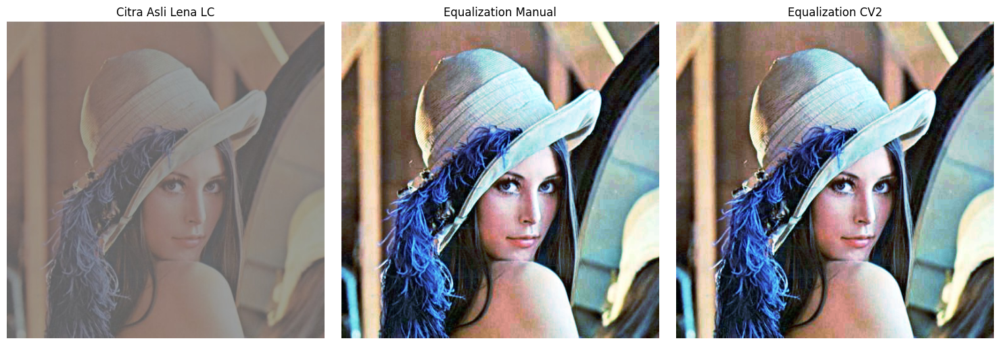


 KTM1a
Selisih maksimum Manual dan CV2: 0


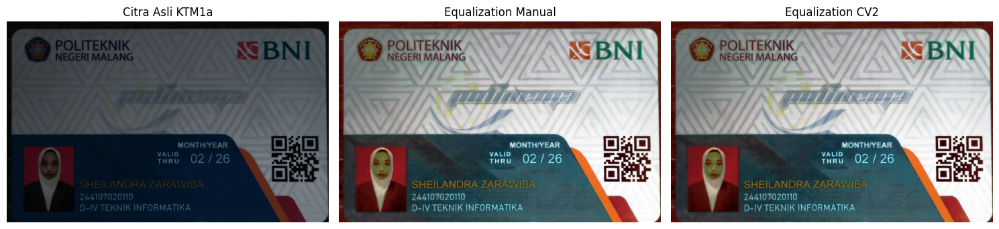

In [22]:
# E-2 Nomor 2
# Perbandingan Equalization Manual dan CV2

def equalize_manual(kanal):
    h = np.zeros(256, dtype=np.int64)

    for y in range(kanal.shape[0]):
        for x in range(kanal.shape[1]):
            h[kanal[y, x]] += 1

    cdf = np.cumsum(h)
    cdf_min = cdf[cdf > 0].min()

    lut = np.round(
        (cdf - cdf_min) / (kanal.size - cdf_min) * 255
    )
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    return lut[kanal]


for nama, path in [
    ('Lena LC', CONTOH + '/lena_lc.jpg'),
    ('KTM1a', BASE + '/KTM1a.jpg')
]:
    img = cv.imread(path)

    if img is None:
        print(nama, 'tidak ditemukan:', path)
        continue

    # Pisahkan kanal BGR
    b, g, r = cv.split(img)

    # Equalization manual
    b_manual = equalize_manual(b)
    g_manual = equalize_manual(g)
    r_manual = equalize_manual(r)
    hasil_manual = cv.merge([b_manual, g_manual, r_manual])

    # Equalization CV2
    b_eq = cv.equalizeHist(b)
    g_eq = cv.equalizeHist(g)
    r_eq = cv.equalizeHist(r)
    hasil_cv2 = cv.merge([b_eq, g_eq, r_eq])

    # Selisih maksimum
    selisih = np.max(
        np.abs(
            hasil_manual.astype(np.int16) -
            hasil_cv2.astype(np.int16)
        )
    )

    print('\n', nama)
    print('Selisih maksimum Manual dan CV2:', selisih)

    # Tampilkan perbandingan
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    axs[0].set_title('Citra Asli ' + nama)

    axs[1].imshow(cv.cvtColor(hasil_manual, cv.COLOR_BGR2RGB))
    axs[1].set_title('Equalization Manual')

    axs[2].imshow(cv.cvtColor(hasil_cv2, cv.COLOR_BGR2RGB))
    axs[2].set_title('Equalization CV2')

    for ax in axs:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

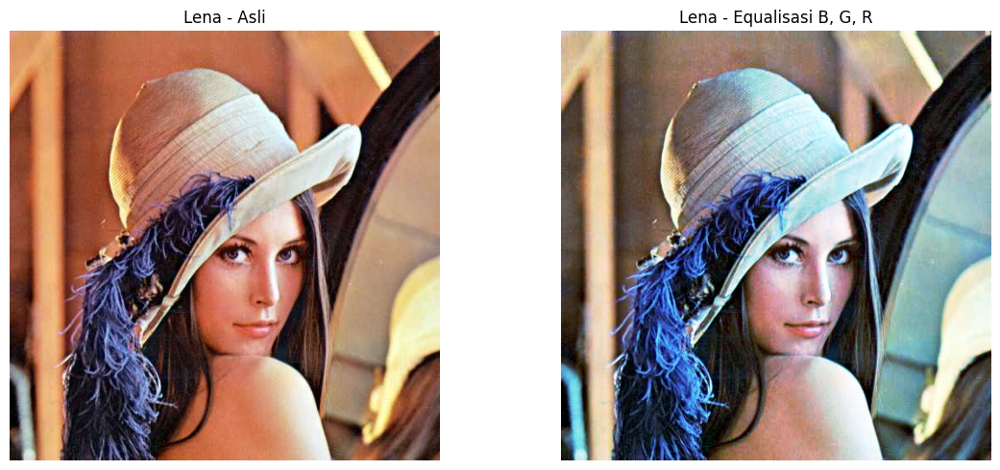

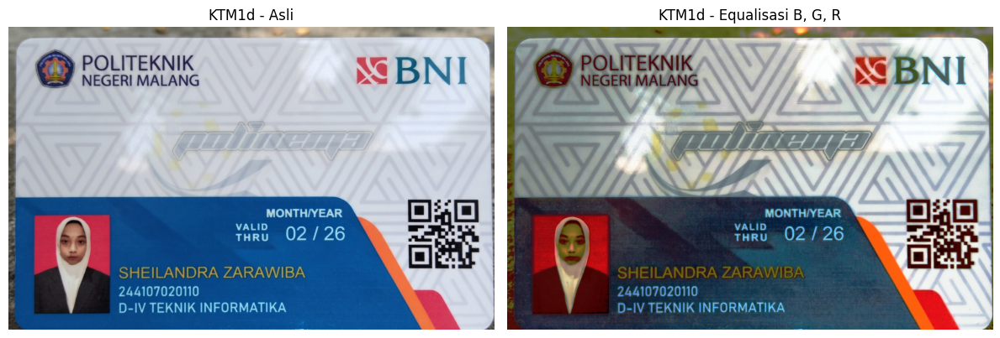

In [23]:
# E-2 Nomor 3
# Equalization pada citra berwarna

for nama, path in [
    ('Lena', CONTOH + '/lena.jpg'),
    ('KTM1d', BASE + '/KTM1d.jpg')
]:
    bgr = cv.imread(path)

    if bgr is None:
        print(nama, 'tidak ditemukan:', path)
        continue

    # Cara 1: Equalization tiap kanal B, G, R
    kanal = list(cv.split(bgr))

    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])

    he_rgb = cv.merge(kanal)

    # Tampilkan citra asli dan hasil
    citra_asli_rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    hasil_rgb = cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].imshow(citra_asli_rgb)
    axs[0].set_title(nama + ' - Asli')
    axs[0].axis('off')

    axs[1].imshow(hasil_rgb)
    axs[1].set_title(nama + ' - Equalisasi B, G, R')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

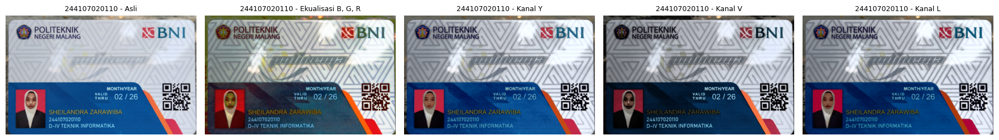

Cara                    Geser Hue (der)    Rerata terang
Asli                               0.00            147.5
Ekualisasi B, G, R                47.61            128.9
Kanal Y                            1.63            129.6
Kanal V                            2.22            111.3
Kanal L                            4.24            121.5


In [24]:
# E-2 Nomor 4
# Perbandingan Equalization kanal terang

bgr = cv.imread(BASE + '/KTM1d.jpg')

if bgr is None:
    print("KTM1d tidak ditemukan")
else:
    # Cara 1: Equalization B, G, R
    kanal = list(cv.split(bgr))

    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])

    he_rgb = cv.merge(kanal)

    # Cara 2: Equalization kanal Y (YCrCb)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)

    he_y = cv.cvtColor(
        cv.merge([cv.equalizeHist(y), cr, cb]),
        cv.COLOR_YCrCb2BGR
    )

    # Equalization kanal V (HSV)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)

    he_v = cv.cvtColor(
        cv.merge([h, sat, cv.equalizeHist(v)]),
        cv.COLOR_HSV2BGR
    )

    # Equalization kanal L (LAB)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, bb = cv.split(lab)

    he_l = cv.cvtColor(
        cv.merge([cv.equalizeHist(l), a, bb]),
        cv.COLOR_LAB2BGR
    )

    # Daftar hasil
    judul = [
        'Asli',
        'Ekualisasi B, G, R',
        'Kanal Y',
        'Kanal V',
        'Kanal L'
    ]

    citra = [bgr, he_rgb, he_y, he_v, he_l]

    # Menampilkan kelima citra
    plt.figure(figsize=(18, 5))

    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Fungsi menghitung pergeseran Hue
    def geser_hue(asli, hasil):
        h1 = cv.cvtColor(
            asli, cv.COLOR_BGR2HSV
        )[:, :, 0].astype(np.int16)

        h2 = cv.cvtColor(
            hasil, cv.COLOR_BGR2HSV
        )[:, :, 0].astype(np.int16)

        d = np.abs(h1 - h2)
        d = np.minimum(d, 180 - d)

        return d.mean()

    # Tabel hasil pengukuran
    print('%-22s %16s %16s' %
          ('Cara', 'Geser Hue (der)', 'Rerata terang'))

    for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' %
              (t,
               geser_hue(bgr, c) * 2,
               cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

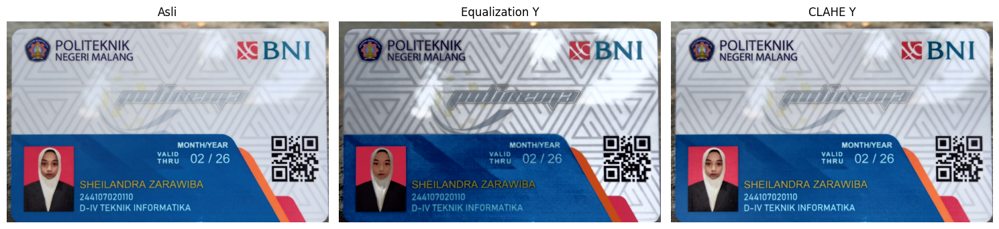

Cara                    Geser Hue (der)    Rerata terang
Asli                               0.00            147.5
Equalization Y                     1.63            129.6
CLAHE Y                            0.03            145.6


In [25]:
# CLAHE pada kanal Y (YCrCb)

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

y_clahe = clahe.apply(y)

hasil_clahe = cv.cvtColor(
    cv.merge([y_clahe, cr, cb]),
    cv.COLOR_YCrCb2BGR
)

# Bandingkan hasil equalization biasa dan CLAHE
judul_banding = ['Asli', 'Equalization Y', 'CLAHE Y']
citra_banding = [bgr, he_y, hasil_clahe]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, c, t in zip(axs, citra_banding, judul_banding):
    ax.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Menghitung pergeseran Hue dan rerata kecerahan
print('%-22s %16s %16s' %
      ('Cara', 'Geser Hue (der)', 'Rerata terang'))

for t, c in zip(judul_banding, citra_banding):
    print('%-22s %16.2f %16.1f' %
          (t,
           geser_hue(bgr, c) * 2,
           cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

PERTANYAAN PRAKTIKUM E2


PSNR Equalization Manual: 9.47 dB
PSNR Equalization CV2: 9.47 dB
Selisih maksimum Manual dan CV2: 0


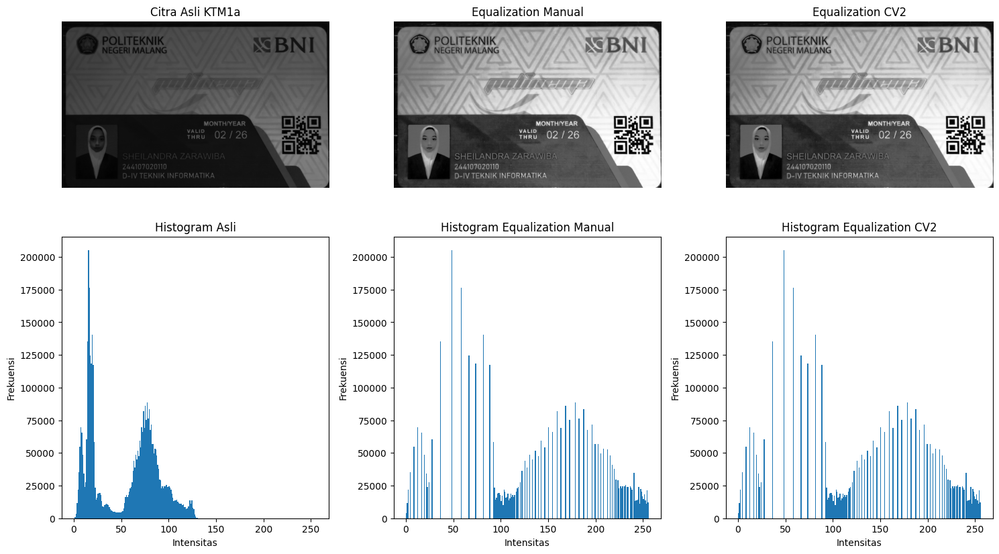

In [26]:
# PERTANYAAN PRAKTIKUM E2 - NOMOR 1
# Ekualisasi Global pada KTM1a Grayscale

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca KTM1a dalam grayscale
img = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

if img is None:
    print("KTM1a.jpg tidak ditemukan:", BASE + '/KTM1a.jpg')

else:
    # a. Histogram equalization manual
    hist = np.zeros(256, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            hist[img[y, x]] += 1

    # Menghitung CDF
    cdf = np.cumsum(hist)
    cdf_min = cdf[cdf > 0].min()

    # Membuat transformasi intensitas
    lut = np.round(
        (cdf - cdf_min) * 255 / (img.size - cdf_min)
    )

    lut = np.clip(lut, 0, 255).astype(np.uint8)

    # Menerapkan transformasi ke citra
    hasil_manual = lut[img]

    # Equalization menggunakan CV2
    hasil_cv2 = cv.equalizeHist(img)

    # c. Menghitung PSNR
    psnr_manual = cv.PSNR(img, hasil_manual)
    psnr_cv2 = cv.PSNR(img, hasil_cv2)

    print("PSNR Equalization Manual:", round(psnr_manual, 2), "dB")
    print("PSNR Equalization CV2:", round(psnr_cv2, 2), "dB")

    # Menghitung selisih maksimum hasil manual dan CV2
    selisih = np.max(
        np.abs(
            hasil_manual.astype(np.int16) -
            hasil_cv2.astype(np.int16)
        )
    )

    print("Selisih maksimum Manual dan CV2:", selisih)

    # b. Menampilkan citra dan histogram dalam satu layout
    fig, axs = plt.subplots(2, 3, figsize=(15, 9))

    # Baris pertama: citra
    axs[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[0, 0].set_title('Citra Asli KTM1a')

    axs[0, 1].imshow(hasil_manual, cmap='gray', vmin=0, vmax=255)
    axs[0, 1].set_title('Equalization Manual')

    axs[0, 2].imshow(hasil_cv2, cmap='gray', vmin=0, vmax=255)
    axs[0, 2].set_title('Equalization CV2')

    # Baris kedua: histogram
    axs[1, 0].hist(img.ravel(), bins=256, range=(0, 256))
    axs[1, 0].set_title('Histogram Asli')

    axs[1, 1].hist(hasil_manual.ravel(), bins=256, range=(0, 256))
    axs[1, 1].set_title('Histogram Equalization Manual')

    axs[1, 2].hist(hasil_cv2.ravel(), bins=256, range=(0, 256))
    axs[1, 2].set_title('Histogram Equalization CV2')

    for ax in axs[0]:
        ax.axis('off')

    for ax in axs[1]:
        ax.set_xlabel('Intensitas')
        ax.set_ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()

ClipLimit awal: 1.0
TileGridSize: (4, 4)


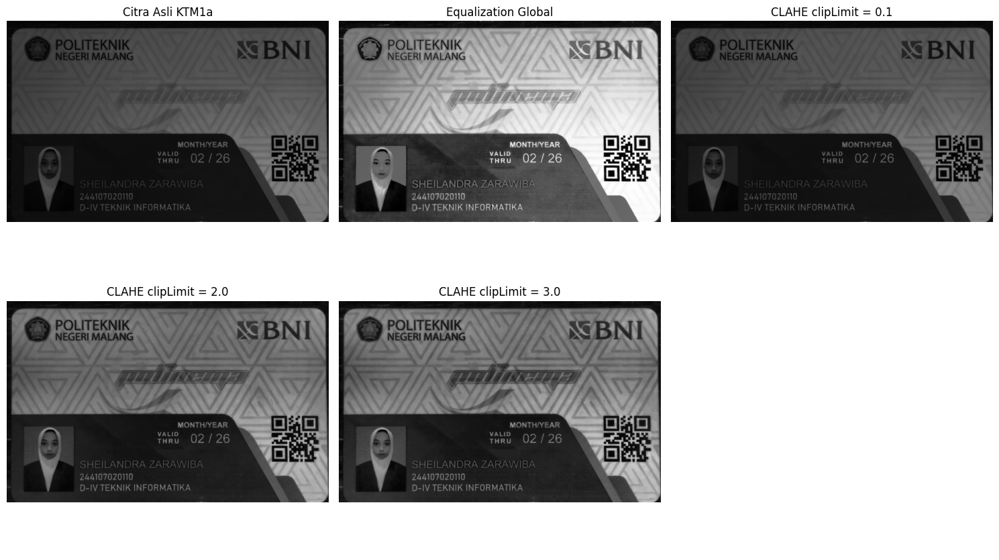

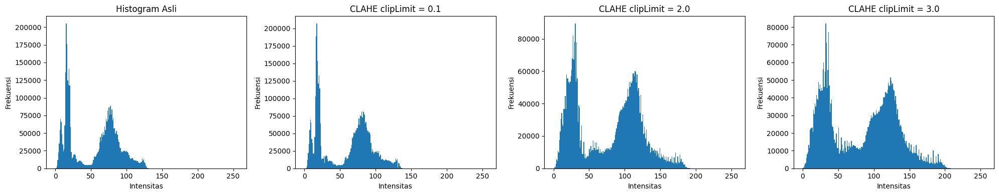

In [27]:
# PERTANYAAN PRAKTIKUM E2 - NOMOR 2
# Ekualisasi Lokal menggunakan CLAHE

img = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

if img is None:
    print("KTM1a.jpg tidak ditemukan")

else:
    # Equalization global sebagai pembanding
    hasil_global = cv.equalizeHist(img)

    # Parameter CLAHE dari NIM
    clip_awal = PARAM['clip']
    tile = PARAM['tile']

    print("ClipLimit awal:", clip_awal)
    print("TileGridSize:", (tile, tile))

    # Membuat nilai clipLimit lain di sekitar parameter
    clip_values = [
        max(0.1, round(clip_awal - 1, 1)),
        max(0.1, round(clip_awal + 1, 1)),
        max(0.1, round(clip_awal + 2, 1))
    ]

    # Menghilangkan nilai duplikat
    clip_values = sorted(set(clip_values))

    # Menyimpan hasil CLAHE
    hasil_clahe = []

    for clip in clip_values:
        clahe = cv.createCLAHE(
            clipLimit=clip,
            tileGridSize=(tile, tile)
        )

        hasil = clahe.apply(img)
        hasil_clahe.append((clip, hasil))

    # Menampilkan citra asli, global, dan CLAHE
    jumlah_gambar = 2 + len(hasil_clahe)

    fig, axs = plt.subplots(
        2, 3, figsize=(15, 9)
    )

    axs = axs.ravel()

    axs[0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[0].set_title('Citra Asli KTM1a')

    axs[1].imshow(hasil_global, cmap='gray', vmin=0, vmax=255)
    axs[1].set_title('Equalization Global')

    for i, (clip, hasil) in enumerate(hasil_clahe, start=2):
        axs[i].imshow(hasil, cmap='gray', vmin=0, vmax=255)
        axs[i].set_title('CLAHE clipLimit = ' + str(clip))

    # Menyembunyikan subplot yang tidak digunakan
    for i in range(jumlah_gambar, len(axs)):
        axs[i].axis('off')

    for ax in axs[:jumlah_gambar]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Histogram hasil CLAHE
    fig, axs = plt.subplots(
        1, len(hasil_clahe) + 1,
        figsize=(5 * (len(hasil_clahe) + 1), 4)
    )

    axs[0].hist(img.ravel(), bins=256, range=(0, 256))
    axs[0].set_title('Histogram Asli')

    for i, (clip, hasil) in enumerate(hasil_clahe, start=1):
        axs[i].hist(hasil.ravel(), bins=256, range=(0, 256))
        axs[i].set_title('CLAHE clipLimit = ' + str(clip))

    for ax in axs:
        ax.set_xlabel('Intensitas')
        ax.set_ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()

E-3 TUGAS PRAKTIKUM DITHERING

Jumlah level intensitas L = 8


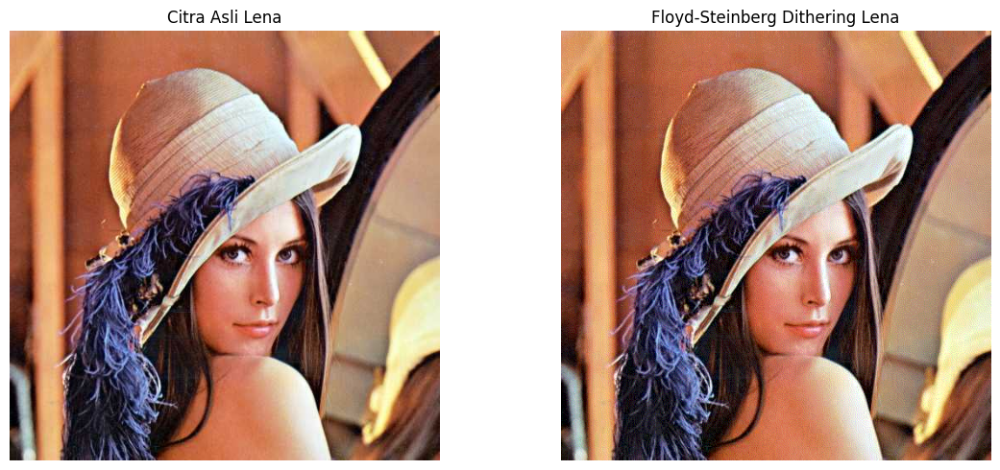

Jumlah level L: 8


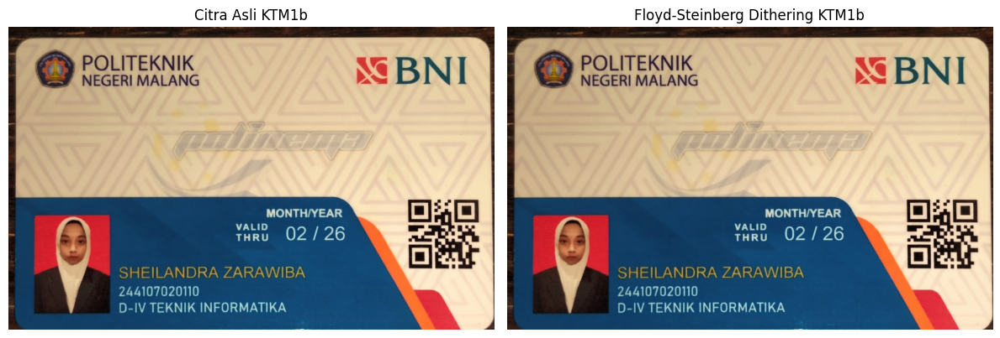

Jumlah level L: 8
B level unik sebelum: 253 | sesudah: 8
G level unik sebelum: 253 | sesudah: 8
R level unik sebelum: 256 | sesudah: 8


In [30]:
# E-3 Nomor 1
# Floyd-Steinberg Dithering pada Lena dan KTM1b

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Fungsi Floyd-Steinberg Dithering
def floyd_steinberg(img, L):
    img = img.astype(np.float32).copy()

    tinggi, lebar = img.shape[:2]
    hasil = np.zeros_like(img, dtype=np.uint8)

    # Jarak antarlevel intensitas
    step = 255 / (L - 1)

    for y in range(tinggi):
        for x in range(lebar):
            nilai_lama = img[y, x]

            # Kuantisasi ke level terdekat
            nilai_baru = np.round(nilai_lama / step) * step
            nilai_baru = np.clip(nilai_baru, 0, 255)

            hasil[y, x] = nilai_baru

            # Menghitung error
            error = nilai_lama - nilai_baru

            # Menyebarkan error ke piksel tetangga
            if x + 1 < lebar:
                img[y, x + 1] += error * 7 / 16

            if y + 1 < tinggi:
                if x - 1 >= 0:
                    img[y + 1, x - 1] += error * 3 / 16

                img[y + 1, x] += error * 5 / 16

                if x + 1 < lebar:
                    img[y + 1, x + 1] += error * 1 / 16

    return hasil


# Menggunakan jumlah level dari parameter NIM
L = PARAM['L']

print("Jumlah level intensitas L =", L)

# Tahap 1: Lena, Tahap 2: KTM1b
for nama, path in [
    ('Lena', CONTOH + '/lena.jpg'),
    ('KTM1b', BASE + '/KTM1b.jpg')
]:
    img = cv.imread(path)

    if img is None:
        print(nama, 'tidak ditemukan:', path)
        continue

    # Dithering setiap kanal BGR
    kanal = cv.split(img)

    hasil_kanal = [
        floyd_steinberg(k, L)
        for k in kanal
    ]

    hasil = cv.merge(hasil_kanal)

    # Menampilkan citra asli dan hasil dithering
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    axs[0].set_title('Citra Asli ' + nama)
    axs[0].axis('off')

    axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    axs[1].set_title('Floyd-Steinberg Dithering ' + nama)
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()
    print("Jumlah level L:", L)

for i, nama_kanal in enumerate(['B', 'G', 'R']):
    print(
        nama_kanal,
        "level unik sebelum:", len(np.unique(img[:, :, i])),
        "| sesudah:", len(np.unique(hasil[:, :, i]))
    )

Jumlah level intensitas L = 8


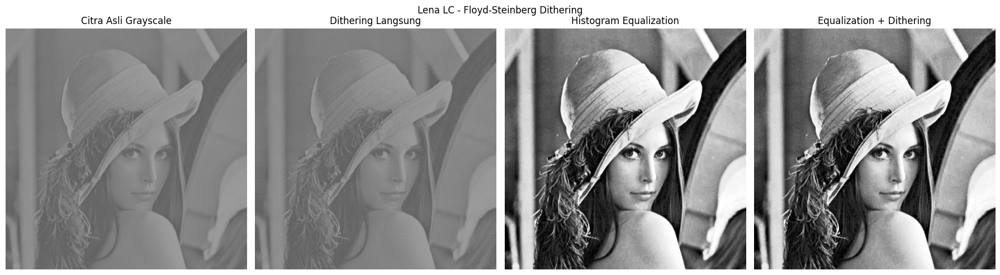

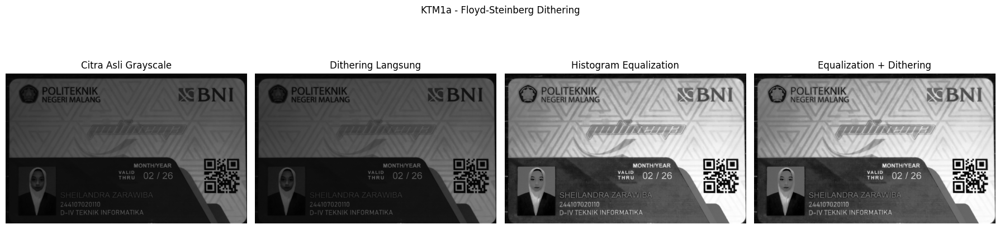

In [29]:
# E-3 Nomor 2
# Grayscale + Histogram Equalization + Floyd-Steinberg Dithering

L = PARAM['L']

print("Jumlah level intensitas L =", L)

for nama, path in [
    ('Lena LC', CONTOH + '/lena_lc.jpg'),
    ('KTM1a', BASE + '/KTM1a.jpg')
]:
    # Membaca citra grayscale
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if img is None:
        print(nama, 'tidak ditemukan:', path)
        continue

    # Histogram Equalization
    hasil_equalization = cv.equalizeHist(img)

    # Dithering langsung tanpa equalization
    dithering_langsung = floyd_steinberg(img, L)

    # Dithering setelah histogram equalization
    dithering_equalization = floyd_steinberg(
        hasil_equalization, L
    )

    # Menampilkan semua hasil dalam satu layout
    judul = [
        'Citra Asli Grayscale',
        'Dithering Langsung',
        'Histogram Equalization',
        'Equalization + Dithering'
    ]

    citra = [
        img,
        dithering_langsung,
        hasil_equalization,
        dithering_equalization
    ]

    fig, axs = plt.subplots(1, 4, figsize=(18, 5))

    for ax, c, t in zip(axs, citra, judul):
        ax.imshow(c, cmap='gray', vmin=0, vmax=255)
        ax.set_title(t)
        ax.axis('off')

    fig.suptitle(nama + ' - Floyd-Steinberg Dithering')
    plt.tight_layout()
    plt.show()